# Iris Flower Classification

In [32]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Data Extraction

In [5]:
data=pd.read_csv("iris_data.csv", names=["Sepal_len_cm","Sepal_width_cm","Petal_len_cm","Petal_width_cm","Species"],header=None)
data.head()

,Sepal_len_cm,Sepal_width_cm,Petal_len_cm,Petal_width_cm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Data Preprocessing
### Dataset Information

In [7]:
 data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sepal_len_cm    150 non-null    float64
 1   Sepal_width_cm  150 non-null    float64
 2   Petal_len_cm    150 non-null    float64
 3   Petal_width_cm  150 non-null    float64
 4   Species         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [9]:
data.columns

Index(['Sepal_len_cm', 'Sepal_width_cm', 'Petal_len_cm', 'Petal_width_cm',
       'Species'],
      dtype='object')

In [11]:
data.describe(include='all').round(2)

,Sepal_len_cm,Sepal_width_cm,Petal_len_cm,Petal_width_cm,Species
count,150.00,150.00,150.00,150.00,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.84,3.05,3.76,1.20,NaN
std,0.83,0.43,1.76,0.76,NaN
min,4.30,2.00,1.00,0.10,NaN
25%,5.10,2.80,1.60,0.30,NaN
50%,5.80,3.00,4.35,1.30,NaN
75%,6.40,3.30,5.10,1.80,NaN


### Data cleaning

In [15]:
#Checking missing values
data.isnull().sum()

Sepal_len_cm      0
Sepal_width_cm    0
Petal_len_cm      0
Petal_width_cm    0
Species           0
dtype: int64

In [17]:
#checking duplicates
print(data.duplicated().sum())
data[data.duplicated()]

3


,Sepal_len_cm,Sepal_width_cm,Petal_len_cm,Petal_width_cm,Species
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


In [19]:
#modifying existing dataset directly without re-assigning
data.drop_duplicates(inplace=True)
print(data.duplicated().sum())
data.shape

0


(147, 5)

In [23]:
data['Species'].value_counts()

Species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

## Data Visualization

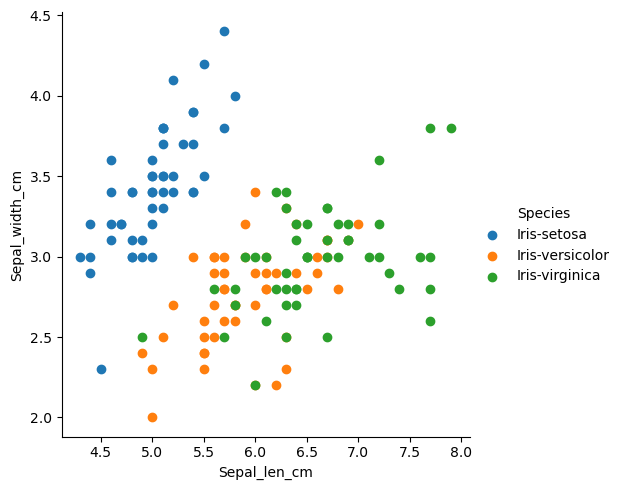

In [80]:
sns.FacetGrid(data, hue='Species',height=5)\
.map(plt.scatter,'Sepal_len_cm','Sepal_width_cm')\
.add_legend()

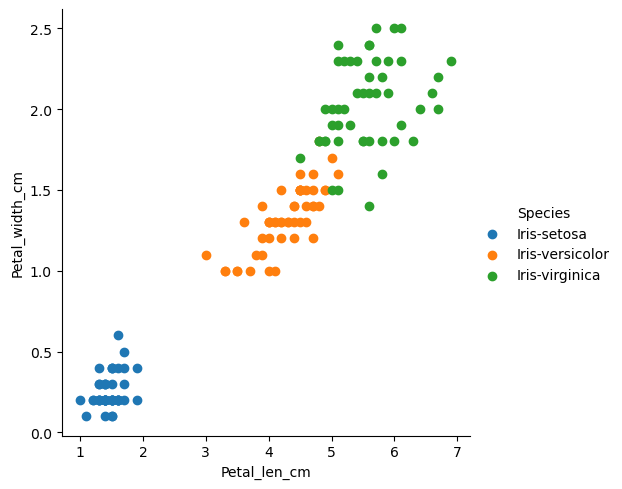

In [82]:
sns.FacetGrid(data, hue='Species',height=5)\
.map(plt.scatter,'Petal_len_cm','Petal_width_cm')\
.add_legend()

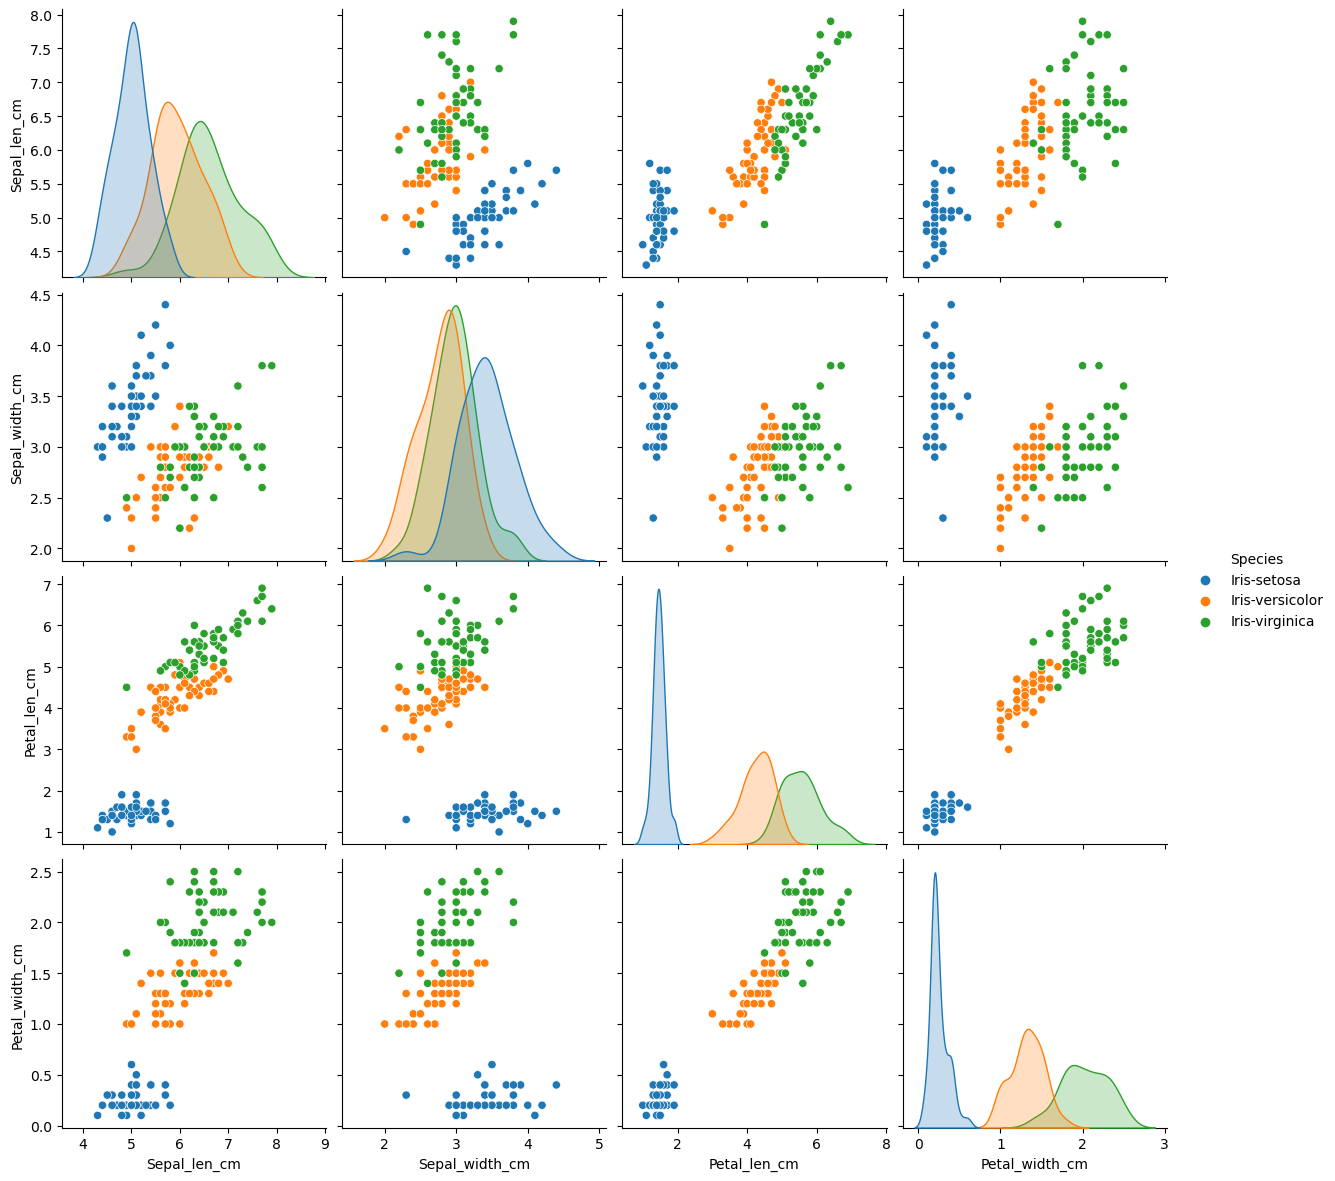

In [84]:
sns.pairplot(data,hue='Species',size=3,diag_kind='kde')

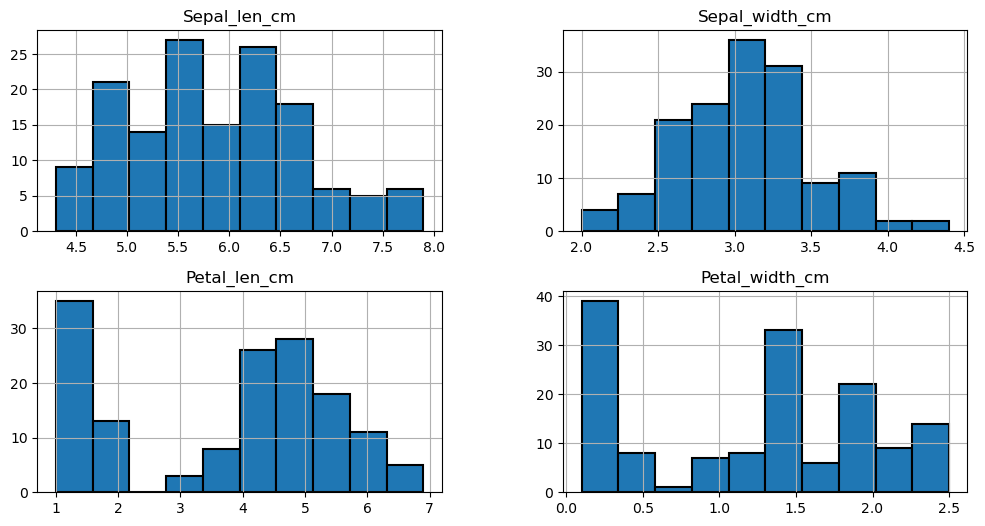

In [96]:
#How the length and width are distributed
data.hist(edgecolor='black', linewidth=1.5)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()

<Axes: xlabel='Species', ylabel='Petal_width_cm'>

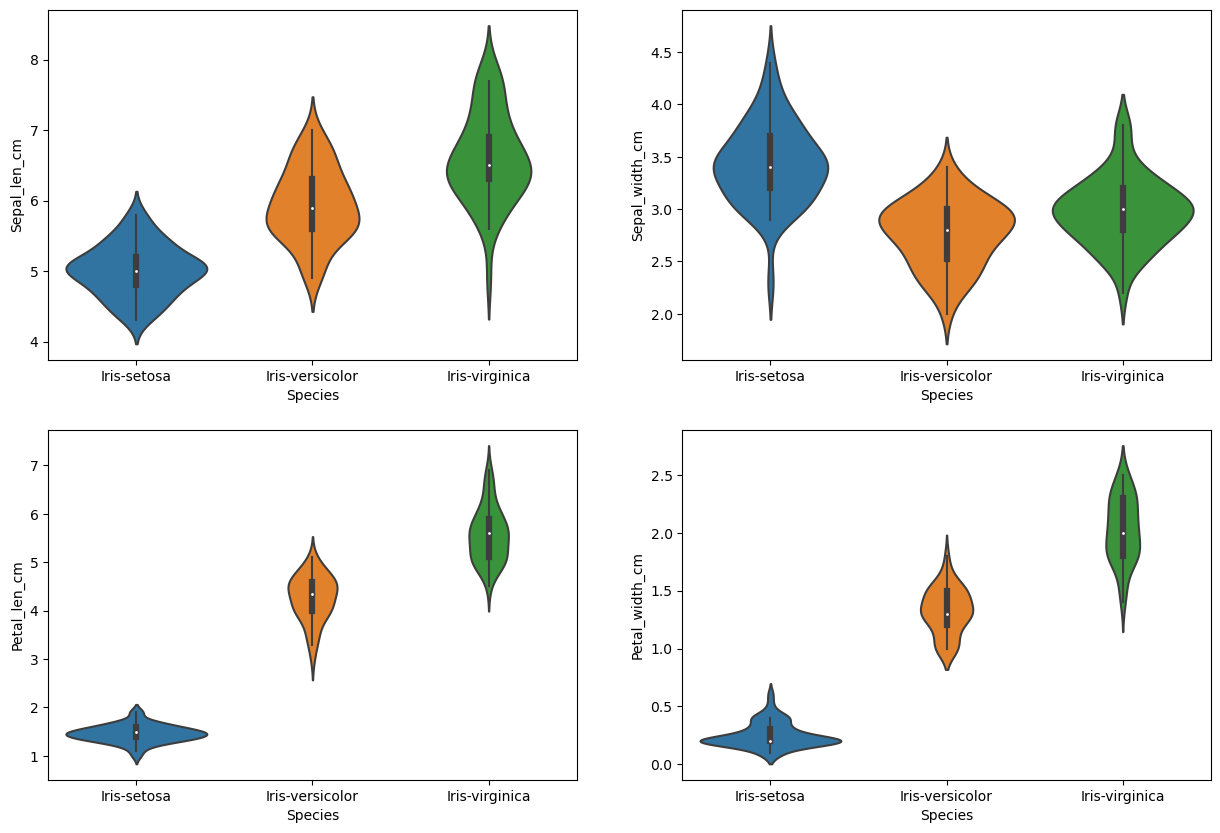

In [98]:
# How length and width vary according to species
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.violinplot(x='Species',y='Sepal_len_cm',data=data)
plt.subplot(2,2,2)
sns.violinplot(x='Species',y='Sepal_width_cm',data=data)
plt.subplot(2,2,3)
sns.violinplot(x='Species',y='Petal_len_cm',data=data)
plt.subplot(2,2,4)
sns.violinplot(x='Species',y='Petal_width_cm',data=data)

## Correlation matrix

In [50]:
corr_matrix=data.drop(columns='Species').corr()
corr_matrix.head()

,Sepal_len_cm,Sepal_width_cm,Petal_len_cm,Petal_width_cm
Sepal_len_cm,1.000000,-0.109321,0.871305,0.817058
Sepal_width_cm,-0.109321,1.000000,-0.421057,-0.356376
Petal_len_cm,0.871305,-0.421057,1.000000,0.961883
Petal_width_cm,0.817058,-0.356376,0.961883,1.000000


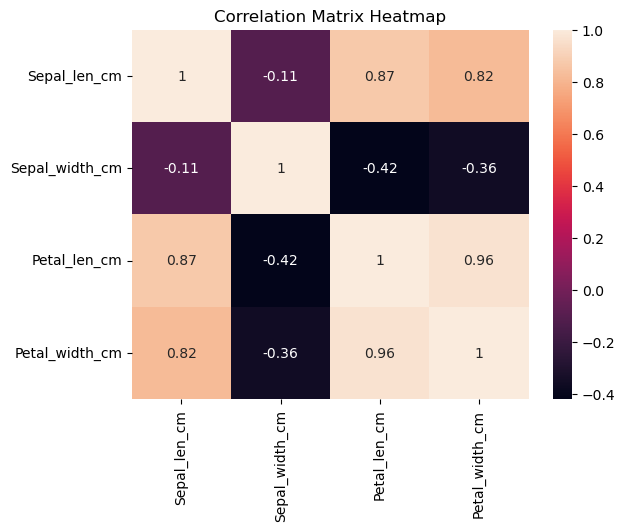

In [54]:
sns.heatmap(corr_matrix,annot=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

## ML Model Implementation

In [57]:
X=data.drop(columns='Species')
y=data['Species']

In [120]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Logistic Regression

In [133]:
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)
y_pred = model_lr.predict(X_test)
print('The accuracy of the Logistic Regression is', accuracy_score(y_pred,y_test))

The accuracy of the Logistic Regression is 0.9333333333333333


In [142]:
-12/10

-1.2

### Support Vector Machine (SVM)

In [147]:
from sklearn import svm


In [149]:
print(dir(svm))

['LinearSVC', 'LinearSVR', 'NuSVC', 'NuSVR', 'OneClassSVM', 'SVC', 'SVR', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_bounds', '_classes', '_liblinear', '_libsvm', '_libsvm_sparse', 'l1_min_c']


In [ ]:
model = svm.SVC()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print('The accuracy of the SVM is:'